# Project Overview
## MCP-Powered Multi-Agent Air Quality Reasoning System
### Data Preparation for Multi-Task Health Impact Estimation

This notebook prepares the air quality and health impact dataset for a **Multi-Task Deep Neural Network** that jointly predicts:

- **HealthImpactScore** (continuous: 0–100)
- **HealthImpactClass** (discrete risk category)

The system is part of a **multi-agent reasoning architecture** where:
- Perception agents process environmental and health signals,
- A reasoning agent infers risk severity,
- An explanation agent communicates the impact to humans.

The dataset contains atmospheric pollutants, meteorological variables, and observed health outcomes used to model pollution-related health risk.


# Step 1: Imports & Setup
Importing standard libraries and also set global configuration for plots to ensure readablit.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.utils.class_weight import compute_class_weight

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries Imported Successfully")

Libraries Imported Successfully


# Step 2: Load Data & Initial Health Check
Verify the data loaded correctly and understand its basic structure (rows, columns, data types).
Look for .info() to see if there are null values and .head() to verify column names.

In [4]:
df = pd.read_csv("air_quality_health_impact_data-4.csv")
print(f"Dataset Shape: {df.shape}")
print("-" * 30)
df.info()
print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (5811, 15)
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5811 entries, 0 to 5810
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   RecordID             5811 non-null   int64  
 1   AQI                  5811 non-null   float64
 2   PM10                 5811 non-null   float64
 3   PM2_5                5811 non-null   float64
 4   NO2                  5811 non-null   float64
 5   SO2                  5811 non-null   float64
 6   O3                   5811 non-null   float64
 7   Temperature          5811 non-null   float64
 8   Humidity             5811 non-null   float64
 9   WindSpeed            5811 non-null   float64
 10  RespiratoryCases     5811 non-null   int64  
 11  CardiovascularCases  5811 non-null   int64  
 12  HospitalAdmissions   5811 non-null   int64  
 13  HealthImpactScore    5811 non-null   float64
 14  HealthImpactClass    5811 non-n

,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
0,1,187.270059,295.853039,13.038560,6.639263,66.161150,54.624280,5.150335,84.424344,6.137755,7,5,1,97.244041,0.0
1,2,475.357153,246.254703,9.984497,16.318326,90.499523,169.621728,1.543378,46.851415,4.521422,10,2,0,100.000000,0.0
2,3,365.996971,84.443191,23.111340,96.317811,17.875850,9.006794,1.169483,17.806977,11.157384,13,3,0,100.000000,0.0
3,4,299.329242,21.020609,14.273403,81.234403,48.323616,93.161033,21.925276,99.473373,15.302500,8,8,1,100.000000,0.0
4,5,78.009320,16.987667,152.111623,121.235461,90.866167,241.795138,9.217517,24.906837,14.534733,9,0,1,95.182643,0.0


# Step 3: Exploratory Data Analysis (EDA)
Before processing, understand what we are predicting.

HealthImpactScore: Check is it a normal distribution or skewed?

HealthImpactClass: Check if it is balanced or not. If not, the model might ignore the minority class.

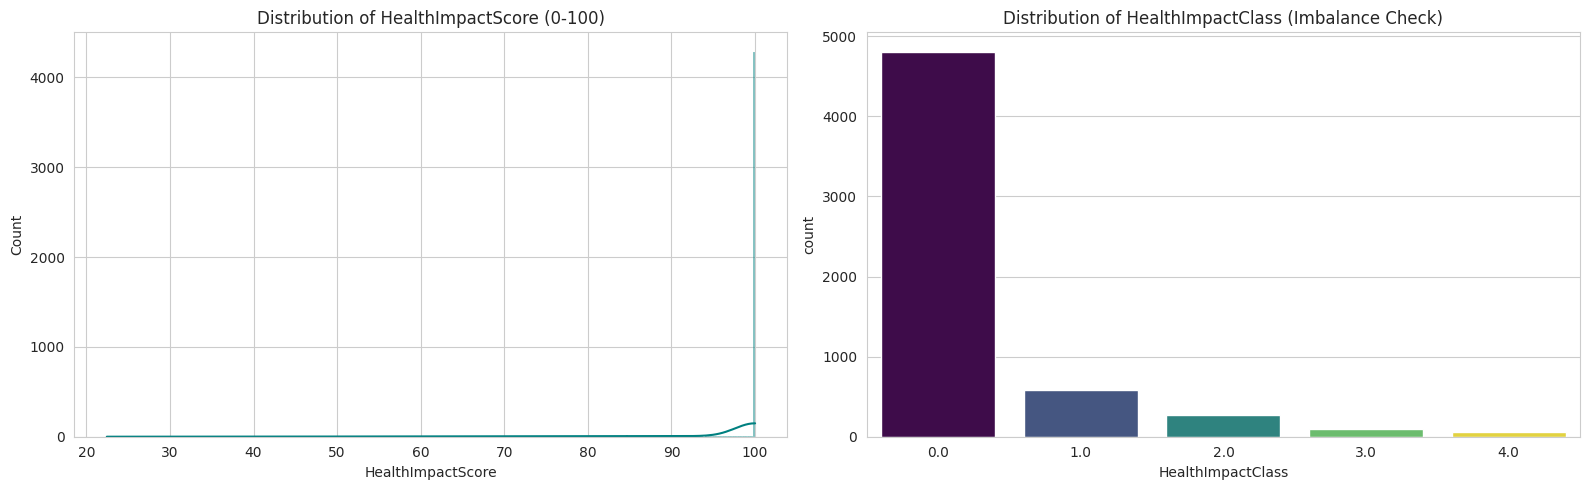

Class Ratios (%):
 HealthImpactClass
0.0    82.739632
1.0     9.963862
2.0     4.697987
3.0     1.634830
4.0     0.963690
Name: proportion, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df["HealthImpactScore"], kde=True, ax=axes[0], color='teal')
axes[0].set_title("Distribution of HealthImpactScore (0-100)")
sns.countplot(x=df["HealthImpactClass"], ax=axes[1], palette="viridis", hue=df["HealthImpactClass"], legend=False)
axes[1].set_title("Distribution of HealthImpactClass (Imbalance Check)")
plt.tight_layout()
plt.show()
print("Class Ratios (%):\n", df["HealthImpactClass"].value_counts(normalize=True) * 100)

# Step 4: Preventing Data Leakage
In a real-world scenario (inference), we will know the PM2.5 (Air Quality), but we won't know how many HospitalAdmissions happened yet—that is what we are trying to predict!

Therefore we drop RespiratoryCases, CardiovascularCases, and HospitalAdmissions from the input features (X).

In [6]:
df["PM_ratio"] = df["PM2_5"] / (df["PM10"] + 1e-6)
df["NO2_O3_interaction"] = df["NO2"] * df["O3"]
leakage_cols = ["RespiratoryCases", "CardiovascularCases", "HospitalAdmissions",
                "HealthImpactScore", "HealthImpactClass", "RecordID"]
X = df.drop(columns=leakage_cols)
y_score = df["HealthImpactScore"]
y_class = df["HealthImpactClass"].astype(int)
print("Input Features (X):", X.columns.tolist())

Input Features (X): ['AQI', 'PM10', 'PM2_5', 'NO2', 'SO2', 'O3', 'Temperature', 'Humidity', 'WindSpeed', 'PM_ratio', 'NO2_O3_interaction']


# Step 5: Stratified Train-Test Split

Since our classes are imbalanced (as seen in EDA), stratify=y_class ensures the Test set has the same proportion of high-risk cases as the Train set.

In [7]:
X_train_raw, X_test_raw, y_score_train_raw, y_score_test, y_class_train_raw, y_class_test = train_test_split(
    X, y_score, y_class,
    test_size=0.2,
    stratify=y_class,
    random_state=42
)
print(f"Train Size: {X_train_raw.shape[0]} samples")
print(f"Test Size:  {X_test_raw.shape[0]} samples")

Train Size: 4648 samples
Test Size:  1163 samples


# Step 6: Outlier Detection
Remove anomalous data points that could confuse the model using IsolationForest. Visualize the data before and after to prove it didn't delete valid high-risk data.

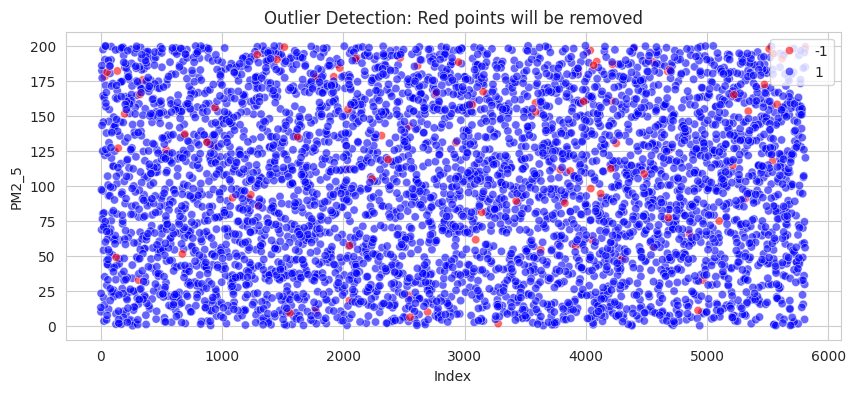

Removed 93 outliers.


In [8]:
iso = IsolationForest(contamination=0.02, random_state=42)
outlier_mask = iso.fit_predict(X_train_raw) # -1 is outlier, 1 is inlier
plt.figure(figsize=(10, 4))
sns.scatterplot(x=X_train_raw.index, y=X_train_raw["PM2_5"],
                hue=outlier_mask, palette={1: "blue", -1: "red"}, alpha=0.6)
plt.title("Outlier Detection: Red points will be removed")
plt.xlabel("Index")
plt.show()
X_train = X_train_raw[outlier_mask == 1]
y_score_train = y_score_train_raw[outlier_mask == 1]
y_class_train = y_class_train_raw[outlier_mask == 1]
print(f"Removed {len(X_train_raw) - len(X_train)} outliers.")

# Step 7: Feature Scaling
Neural networks work best when all inputs are roughly in the same range (e.g., -1 to 1).
Before scaling PM10 might be 150, while NO2 is 0.5. After scaling both will have a mean of 0. Fit the scaler on Train data and apply it to Test data.

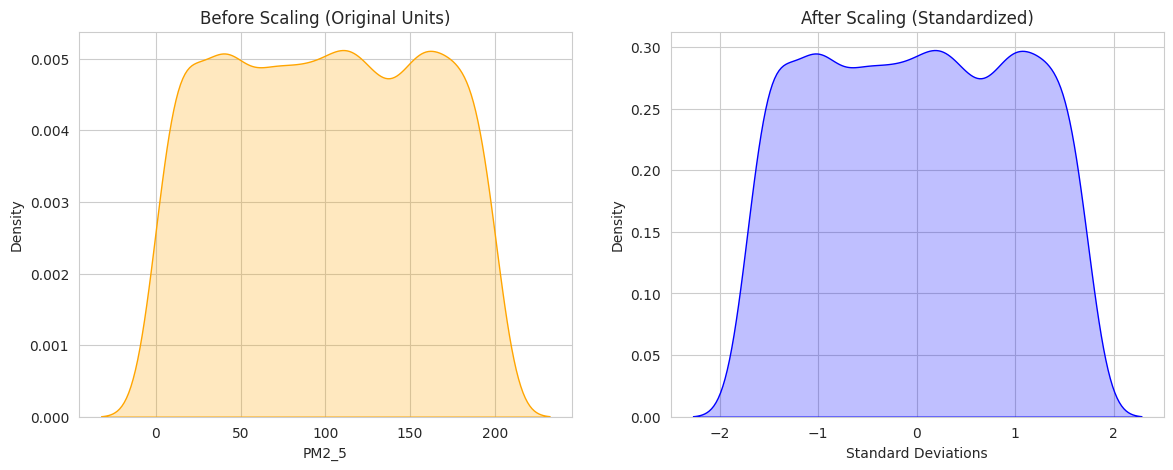

Scaled Data Mean (first 5 features): [-0.  0.  0.  0. -0.]
Scaled Data Std  (first 5 features): [1. 1. 1. 1. 1.]


In [9]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test_raw)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.kdeplot(X_train["PM2_5"], ax=axes[0], fill=True, color='orange')
axes[0].set_title("Before Scaling (Original Units)")
sns.kdeplot(X_train_scaled[:, 2], ax=axes[1], fill=True, color='blue')
axes[1].set_title("After Scaling (Standardized)")
axes[1].set_xlabel("Standard Deviations")
plt.show()
print("Scaled Data Mean (first 5 features):", X_train_scaled.mean(axis=0)[:5].round(2))
print("Scaled Data Std  (first 5 features):", X_train_scaled.std(axis=0)[:5].round(2))

# Step 8: Target Scaling
The regression target HealthImpactScore ranges from 0 to 100. Why Scale? Large target values can cause "exploding gradients" in Deep Learning. We squash the score to [0, 1].

In [10]:
scaler_y = MinMaxScaler()
y_score_train_scaled = scaler_y.fit_transform(y_score_train.values.reshape(-1, 1))
y_score_test_scaled = scaler_y.transform(y_score_test.values.reshape(-1, 1))
print("Min Score (Scaled):", y_score_train_scaled.min())
print("Max Score (Scaled):", y_score_train_scaled.max())

Min Score (Scaled): 0.0
Max Score (Scaled): 1.0


# Step 9: Class Weighting
Since we have fewer "High Risk" samples, the model might get lazy and just predict "Low Risk" all the time. Therefore we calculate weights. If Class 4 is rare, it gets a higher weight, penalizing the model more if it gets it wrong.


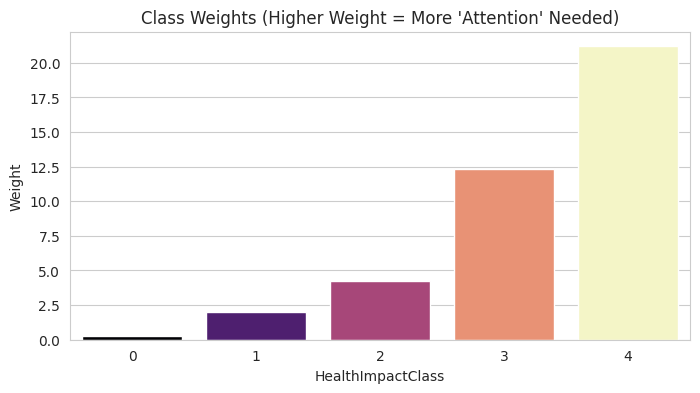

Calculated Class Weights: {np.int64(0): np.float64(0.2416445623342175), np.int64(1): np.float64(2.0066079295154187), np.int64(2): np.float64(4.257009345794392), np.int64(3): np.float64(12.31081081081081), np.int64(4): np.float64(21.186046511627907)}


In [11]:
classes = np.unique(y_class_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_class_train)
class_weight_dict = dict(zip(classes, weights))
plt.figure(figsize=(8, 4))
sns.barplot(x=list(class_weight_dict.keys()), y=list(class_weight_dict.values()), palette="magma", hue=list(class_weight_dict.keys()), legend=False)
plt.title("Class Weights (Higher Weight = More 'Attention' Needed)")
plt.xlabel("HealthImpactClass")
plt.ylabel("Weight")
plt.show()
print("Calculated Class Weights:", class_weight_dict)

# Step 10: Final Data Preparation Summary
The data is now fully preprocessed and ready for the Multi-Task DNN model training.


Outputs:
1. X_train_scaled: Features (Normalized)
2. y_score_train_scaled: Regression Target (0-1)
3. y_class_train: Classification Target (Integers)
4. class_weight_dict: For the Loss Function

In [12]:
print("--- Final Data Shapes ---")
print(f"Features (Train): {X_train_scaled.shape}")
print(f"Features (Test):  {X_test_scaled.shape}")
print(f"Regression Target (Train): {y_score_train_scaled.shape}")
print(f"Classification Target (Train): {y_class_train.shape}")

--- Final Data Shapes ---
Features (Train): (4555, 11)
Features (Test):  (1163, 11)
Regression Target (Train): (4555, 1)
Classification Target (Train): (4555,)


## Base Model without tuning

In [20]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np

input_shape = X_train_scaled.shape[1]
num_classes = len(np.unique(y_class_train))

def get_base_model():
    inputs = layers.Input(shape=(input_shape,), name="input_features")
    shared = layers.Dense(64, activation='relu')(inputs)
    shared = layers.BatchNormalization()(shared)
    shared = layers.Dropout(0.2)(shared)
    shared = layers.Dense(32, activation='relu')(shared)

    score_output = layers.Dense(1, activation='linear', name='score_output')(shared)
    class_output = layers.Dense(num_classes, activation='softmax', name='class_output')(shared)

    model = Model(inputs=inputs, outputs=[score_output, class_output])
    model.compile(
        optimizer='adam',
        loss={'score_output': 'mse', 'class_output': 'sparse_categorical_crossentropy'},
        metrics={'score_output': 'mae', 'class_output': 'accuracy'}
    )
    return model

base_model = get_base_model()

# Calculate sample weights for the classification task
sample_weights_for_classification = np.array([class_weight_dict[cls] for cls in y_class_train])

# Provide targets and sample_weight as lists, matching the model's output order
base_model.fit(
    X_train_scaled,
    [y_score_train_scaled, y_class_train], # Targets as a list, order: score_output, class_output
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    sample_weight=[np.ones(len(y_score_train_scaled)), sample_weights_for_classification], # Sample weights as a list
    verbose=1
)


Epoch 1/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - class_output_accuracy: 0.3879 - class_output_loss: 1.9142 - loss: 2.5283 - score_output_loss: 0.6141 - score_output_mae: 0.5961 - val_class_output_accuracy: 0.4841 - val_class_output_loss: 1.6027 - val_loss: 1.9132 - val_score_output_loss: 0.3035 - val_score_output_mae: 0.5142
Epoch 2/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - class_output_accuracy: 0.4507 - class_output_loss: 1.4630 - loss: 1.6379 - score_output_loss: 0.1749 - score_output_mae: 0.3271 - val_class_output_accuracy: 0.4468 - val_class_output_loss: 1.5461 - val_loss: 1.6990 - val_score_output_loss: 0.1459 - val_score_output_mae: 0.3345
Epoch 3/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - class_output_accuracy: 0.4503 - class_output_loss: 1.3213 - loss: 1.4358 - score_output_loss: 0.1145 - score_output_mae: 0.2654 - val_class_output_accuracy: 0.4709 - val_class_output_loss: 1.5354 - val_loss: 1.6224 - val_score_output_loss: 0.0801 - val_score_output_mae: 0.2313
Epo

## Hyperparameter Tuning

In [23]:
import keras_tuner as kt

def build_tuning_model(hp):
    inputs = layers.Input(shape=(input_shape,), name="input_features")
    shared = inputs
    for i in range(hp.Int('num_layers', 1, 3)):
        shared = layers.Dense(
            units=hp.Int(f'units_{i}', 32, 128, step=32),
            activation='relu'
        )(shared)
        shared = layers.Dropout(hp.Float(f'dropout_{i}', 0.1, 0.4, step=0.1))(shared)

    score_output = layers.Dense(1, activation='linear', name='score_output')(shared)
    class_output = layers.Dense(num_classes, activation='softmax', name='class_output')(shared)

    model = Model(inputs=inputs, outputs=[score_output, class_output])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(hp.Float('lr', 1e-4, 1e-2, sampling='log')),
        loss={'score_output': 'mse', 'class_output': 'sparse_categorical_crossentropy'},
        metrics={'score_output': 'mae', 'class_output': 'accuracy'}
    )
    return model

tuner = kt.Hyperband(
    build_tuning_model,
    objective=kt.Objective("val_class_output_accuracy", direction="max"),
    max_epochs=20,
    directory='tuning_results',
    project_name='air_quality_mcp'
)

# Calculate sample weights for the classification task
sample_weights_for_classification_tuning = np.array([class_weight_dict[cls] for cls in y_class_train])

tuner.search(
    X_train_scaled,
    [y_score_train_scaled, y_class_train], # Change y to a list
    validation_split=0.2,
    sample_weight=[np.ones(len(y_score_train_scaled)), sample_weights_for_classification_tuning] # Use sample_weight as a list
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]


Trial 26 Complete [00h 00m 18s]
val_class_output_accuracy: 0.6805707812309265

Best val_class_output_accuracy So Far: 0.7014269828796387
Total elapsed time: 00h 05m 52s


In [26]:
import tf2onnx
import onnx

best_model = tuner.hypermodel.build(best_hps)

# Calculate sample weights for the classification task for the final model fit
sample_weights_for_classification_final = np.array([class_weight_dict[cls] for cls in y_class_train])

# Prepare the sample_weight list for model.fit, matching the output order
sample_weights_list = [
    np.ones(len(y_score_train_scaled)), # Uniform weights for the regression output
    sample_weights_for_classification_final # Specific weights for the classification output
]

best_model.fit(
    X_train_scaled,
    [y_score_train_scaled, y_class_train], # Change y to a list, matching sample_weight structure
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    sample_weight=sample_weights_list, # Use sample_weight as a list
    verbose=1
)

best_model.save('best_air_quality_model.keras')

spec = (tf.TensorSpec((None, input_shape), tf.float32, name="input_features"),)
onnx_model, _ = tf2onnx.convert.from_keras(best_model, input_signature=spec, opset=13)
onnx.save(onnx_model, "best_air_quality_model.onnx")

Epoch 1/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - class_output_accuracy: 0.1859 - class_output_loss: 1.5714 - loss: 1.7471 - score_output_loss: 0.1757 - score_output_mae: 0.3120 - val_class_output_accuracy: 0.0922 - val_class_output_loss: 1.5276 - val_loss: 1.5636 - val_score_output_loss: 0.0312 - val_score_output_mae: 0.1416
Epoch 2/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - class_output_accuracy: 0.2784 - class_output_loss: 1.3596 - loss: 1.4097 - score_output_loss: 0.0501 - score_output_mae: 0.1782 - val_class_output_accuracy: 0.4105 - val_class_output_loss: 1.4793 - val_loss: 1.5119 - val_score_output_loss: 0.0228 - val_score_output_mae: 0.1270
Epoch 3/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - class_output_accuracy: 0.3591 - class_output_loss: 1.2471 - loss: 1.2784 - score_output_loss: 0.0313 - score_output_mae: 0.1397 - val_class_output_accuracy: 0.0955 - val_class_output_loss: 1.7557 - val_loss: 1.7839 - val_score_output_loss: 0.0276 - val_score_output_mae: 0.1271
Epo

ERROR:tf2onnx.tfonnx:rewriter <function rewrite_constant_fold at 0x7c67887f9d00>: exception `np.cast` was removed in the NumPy 2.0 release. Use `np.asarray(arr, dtype=dtype)` instead.


In [27]:
print("--- Final Metrics for Base Model ---")
if hasattr(base_model, 'history') and base_model.history:
    history = base_model.history.history
    print(f"Train Loss: {history['loss'][-1]:.4f}")
    print(f"Train MAE (Score): {history['score_output_mae'][-1]:.4f}")
    print(f"Train Accuracy (Class): {history['class_output_accuracy'][-1]:.4f}")
    print(f"Validation Loss: {history['val_loss'][-1]:.4f}")
    print(f"Validation MAE (Score): {history['val_score_output_mae'][-1]:.4f}")
    print(f"Validation Accuracy (Class): {history['val_class_output_accuracy'][-1]:.4f}")
else:
    print("Base model history not found. Please ensure the base model was trained.")

print("\n--- Final Metrics for Best Tuned Model ---")
if hasattr(best_model, 'history') and best_model.history:
    history = best_model.history.history
    print(f"Train Loss: {history['loss'][-1]:.4f}")
    print(f"Train MAE (Score): {history['score_output_mae'][-1]:.4f}")
    print(f"Train Accuracy (Class): {history['class_output_accuracy'][-1]:.4f}")
    print(f"Validation Loss: {history['val_loss'][-1]:.4f}")
    print(f"Validation MAE (Score): {history['val_score_output_mae'][-1]:.4f}")
    print(f"Validation Accuracy (Class): {history['val_class_output_accuracy'][-1]:.4f}")
else:
    print("Best tuned model history not found. Please ensure the best tuned model was trained.")

--- Final Metrics for Base Model ---
Train Loss: 1.1998
Train MAE (Score): 0.1375
Train Accuracy (Class): 0.5110
Validation Loss: 1.6005
Validation MAE (Score): 0.1082
Validation Accuracy (Class): 0.4907

--- Final Metrics for Best Tuned Model ---
Train Loss: 0.6102
Train MAE (Score): 0.0667
Train Accuracy (Class): 0.6874
Validation Loss: 1.7529
Validation MAE (Score): 0.0441
Validation Accuracy (Class): 0.6564
